In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [ ]:
def random_clifford_t_block(qc, q1, q2, add_t, p_t=0.2):
    for q in [q1, q2]:
        r = np.random.randint(4)
        if r == 0:
            qc.h(q)
        elif r == 1:
            qc.s(q)
        elif r == 2:
            qc.h(q)
            qc.s(q)

    if np.random.rand() < 0.5:
        qc.cx(q1, q2)
    else:
        qc.cx(q2, q1)

    if add_t:
        if np.random.rand() < p_t:
            qc.t(q1)
        if np.random.rand() < p_t:
            qc.t(q2)


def build_circuit_2d(Lx, Ly, d, add_t, p_t=0.2):
    N = Lx * Ly
    qc = QuantumCircuit(N)

    def idx(x, y):
        return y * Lx + x

    for layer in range(d):
        direction = layer % 2
        offset = (layer // 2) % 2

        gates_added = False
        if direction == 0:
            for y in range(Ly):
                for x in range(offset, Lx - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x + 1, y), add_t=add_t, p_t=p_t)
                    gates_added = True
        else:
            for x in range(Lx):
                for y in range(offset, Ly - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x, y + 1), add_t=add_t, p_t=p_t)
                    gates_added = True

        if gates_added:
            qc.barrier()

    return qc


def exact_projected_cp(qc, n_measured):
    """
    Computes the exact projected ensemble collision probability:

        2^n_projected * sum_x p(x) * sum_y p(y|x)^2

    where x = outcome on the n_measured rightmost qubits (paper's B, measured subsystem)
          y = outcome on the remaining n_projected qubits (paper's A, projected subsystem)
    """
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()
    N = int(np.log2(len(probs)))
    n_projected = N - n_measured

    # probs_2d[y, x] = p(y_projected, x_measured)
    probs_2d = probs.reshape(2**n_projected, 2**n_measured)

    p_x = probs_2d.sum(axis=0)            # marginal over projected: shape (2^n_measured,)
    sum_p2_per_x = (probs_2d**2).sum(axis=0)  # sum_y p(y,x)^2 for each x

    # sum_x p(x) * sum_y p(y|x)^2 = sum_x [sum_y p(y,x)^2] / p(x)
    mask = p_x > 1e-15
    cp = np.sum(sum_p2_per_x[mask] / p_x[mask])

    return (2**n_projected) * cp

L=2, N=4, n_measured=2, n_projected=2
  saved exact_cp_d10_upto_N4.png
L=3, N=9, n_measured=4, n_projected=5
  saved exact_cp_d10_upto_N9.png
L=4, N=16, n_measured=8, n_projected=8
  saved exact_cp_d10_upto_N16.png


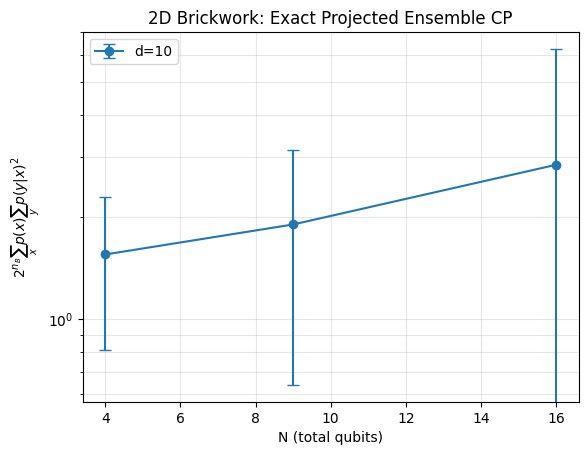

In [7]:
# Vary N, fixed depth
# Statevector is feasible up to ~N=25 (L=5); memory doubles with each qubit
L_values = list(range(2, 5))   # N = 4, 9, 16, 25
d = 10
add_t = False
samples_per_n = 20
output_dir = "results/exact_sv"
os.makedirs(output_dir, exist_ok=True)

avg_prob, std_prob, total_qubits = [], [], []

for L in L_values:
    N = L * L
    n_measured = N // 2
    n_projected = N - n_measured
    print(f"L={L}, N={N}, n_measured={n_measured}, n_projected={n_projected}")
    vals = []

    for _ in range(samples_per_n):
        qc = build_circuit_2d(L, L, d, add_t, p_t=0.15)
        vals.append(exact_projected_cp(qc, n_measured))

    avg_prob.append(np.mean(vals))
    std_prob.append(np.std(vals))
    total_qubits.append(N)

    fig, ax = plt.subplots()
    ax.errorbar(total_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"d={d}")
    ax.set_xlabel("N (total qubits)")
    ax.set_ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
    ax.set_yscale('log')
    ax.set_title(f"2D Brickwork: Exact Projected Ensemble CP")
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.savefig(os.path.join(output_dir, f"exact_cp_d{d}_upto_N{N}.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  saved exact_cp_d{d}_upto_N{N}.png")

plt.errorbar(total_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"d={d}")
plt.xlabel("N (total qubits)")
plt.ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
plt.yscale('log')
plt.title(f"2D Brickwork: Exact Projected Ensemble CP")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

d=1, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d1.png
d=2, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d2.png
d=3, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d3.png
d=4, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d4.png
d=5, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d5.png
d=6, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d6.png
d=7, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d7.png
d=8, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d8.png
d=9, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d9.png
d=10, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d10.png
d=11, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d11.png
d=12, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d12.png
d=13, N=16, n_measured=8, n_projected=8
  saved exact_cp_N16_upto_d13.png
d=14, N=16, n_measured=8, n_projected=8
  saved exact_cp

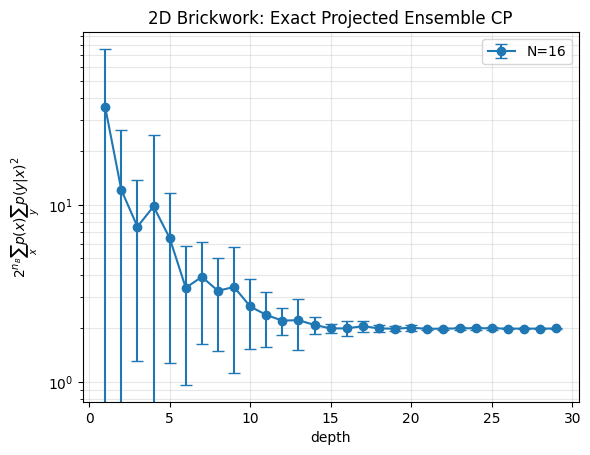

: 

In [ ]:
# Vary depth, fixed N
L = 4
d_values = list(range(1, 30))
add_t = True
samples_per_d = 20
output_dir = "results/exact_sv"
os.makedirs(output_dir, exist_ok=True)

N = L * L
n_measured = N // 2
n_projected = N - n_measured

avg_prob, std_prob, completed_depths = [], [], []

for d in d_values:
    print(f"d={d}, N={N}, n_measured={n_measured}, n_projected={n_projected}")
    vals = []

    for _ in range(samples_per_d):
        qc = build_circuit_2d(L, L, d, add_t, p_t=0.15)
        vals.append(exact_projected_cp(qc, n_measured))

    avg_prob.append(np.mean(vals))
    std_prob.append(np.std(vals))
    completed_depths.append(d)

    fig, ax = plt.subplots()
    ax.errorbar(completed_depths, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"N={N}")
    ax.set_xlabel("depth")
    ax.set_ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
    ax.set_yscale('log')
    ax.set_title(f"2D Brickwork: Exact Projected Ensemble CP")
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.savefig(os.path.join(output_dir, f"exact_cp_N{N}_upto_d{d}.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  saved exact_cp_N{N}_upto_d{d}.png")

plt.errorbar(completed_depths, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"N={N}")
plt.xlabel("depth")
plt.ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
plt.yscale('log')
plt.title(f"2D Brickwork: Exact Projected Ensemble CP")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()